# NeuroSegment-BraTS: Treinamento do Modelo (Deep Learning)

**Notebook 4:** Modelagem e Experimentação

Nesta etapa, instanciamos a arquitetura da rede neural, definimos os parâmetros de otimização e executamos o ciclo de treinamento.

**Metodologia Experimental:**
*   **Modelo:** U-Net 3D (arquitetura padrão ouro para segmentação médica volumétrica).
*   **Função de Perda:** `DiceCELoss`. Uma combinação da *Cross-Entropy* (para classificação geral) com a *Dice Loss* (para otimizar o ganho sobre o desbalanceamento das classes tumorais).
*   **Otimizador:** Adam, que se ajusta bem a gradientes esparsos.
*   **Gestão de Hardware:** Como o sistema possui restrições de memória (16GB RAM/VRAM), o treinamento será feito em "Patches" (blocos menores de 96x96x96 gerados no *DataLoader*) e a validação será reconstruída via `SlidingWindowInferer`.

## 1. Importações e Inicialização

In [2]:
import os
import torch
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinamento rodando no dispositivo: {device}")

if device.type == 'cuda':
    torch.cuda.empty_cache()

# Post-processing para validação
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

Treinamento rodando no dispositivo: cuda


## 2. Ingestão do Pipeline de Dados
Abaixo, conectamos este notebook aos iteradores criados no Notebook 3.

In [3]:
import sys
sys.path.append('../')
from src.data_pipeline import get_dataloaders

# 1. Ingestão do Pipeline
train_loader, val_loader = get_dataloaders()
print("DataLoaders carregados com sucesso no Notebook 4!")

# Validando a conexão (assumindo que train_loader e val_loader estão definidos no kernel)
test_batch = next(iter(train_loader))
print(f"Shape de entrada da imagem: {test_batch['image'].shape}") 
# Esperado: (Batch, Canais, X, Y, Z) -> ex: (2, 4, 96, 96, 96)

Total de pacientes carregados na tubulação: 368
DataLoaders carregados com sucesso no Notebook 4!


/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape de entrada da imagem: torch.Size([16, 4, 128, 128, 128])


## 3. Definição da Arquitetura (U-Net 3D) e Hiperparâmetros
Configuramos a U-Net para aceitar 4 canais de entrada (FLAIR, T1, T1ce, T2) e devolver predições para as nossas 4 classes de interesse (0, 1, 2, 4).

In [4]:
# 1. O Modelo: U-Net Tridimensional
model = UNet(
    spatial_dims=3,             # Imagem 3D
    in_channels=4,              # 4 Modalidades (FLAIR, T1, T1ce, T2)
    out_channels=4,             # 4 Classes de saída (Fundo/Normal, NCR, ED, ET)
    channels=(16, 32, 64, 128, 256), # Número de filtros por camada (mantido leve por causa dos 16GB de VRAM)
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# 2. A Função de Perda (Loss Function)
# Combina Softmax (CrossEntropy) com a métrica espacial (Dice)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# 3. O Otimizador
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

# 4. A Métrica de Avaliação Oficial (Dice Score)
# Mede a sobreposição entre a máscara da IA e o gabarito do médico
dice_metric = DiceMetric(include_background=False, reduction="mean")

## 4. O Ciclo de Treinamento e Validação
Executamos o treinamento iterativo. A cada *batch*, o modelo tenta segmentar o tumor, calcula o erro e ajusta seus pesos. Ao final de cada época, rodamos uma etapa de validação (sem aprender) para medir a performance real.

In [4]:
# Configurações do Loop
max_epochs = 100  # PARA TESTE. Aumente para 50+ na versão final
val_interval = 4 # Roda validação a cada 2 épocas

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# --- ADIÇÃO EARLY STOPPING ---
patience = 15  # Número máximo de validações sem melhoria antes de parar
patience_counter = 0
# -----------------------------

print("INICIANDO O TREINAMENTO...")

for epoch in range(max_epochs):
    print(f"\n--- Época {epoch + 1}/{max_epochs} ---")
    
    # === MODO DE TREINO ===
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        # Enviando dados para a GPU
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        
        # O Ciclo do Gradiente
        optimizer.zero_grad()       # Limpa o "lixo" anterior
        outputs = model(inputs)     # Predição (Aposta da IA)
        loss = loss_function(outputs, labels) # Cálculo do Erro
        loss.backward()             # Propagação para trás
        optimizer.step()            # Ajuste dos pesos
        
        epoch_loss += loss.item()
        
        if step % 10 == 0: # Imprime o status a cada 10 lotes processados
            print(f"Lote {step}/{len(train_loader)} | Loss do Lote: {loss.item():.4f}")
            
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"--> Loss Médio da Época {epoch + 1}: {epoch_loss:.4f}")
    
    # === MODO DE VALIDAÇÃO ===
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad(): # Desliga o aprendizado para economizar memória
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)
                
                # A Reconstrução (Sliding Window):
                # Como a imagem de validação é o cérebro inteiro e não cabe na VRAM,
                # o MONAI "escorrega" uma janela de 96x96x96 por todo o cérebro, processa os pedaços e cola tudo no final.
                val_outputs = sliding_window_inference(
                    inputs=val_inputs, 
                    roi_size=(128, 128, 128), 
                    sw_batch_size=4, 
                    predictor=model
                )
                
                # Formata a saída (Probabilidades para Classes Discretas)
                                
                # Post-processing correto: argmax + one-hot para predições e labels
                val_outputs = [post_pred(i) for i in val_outputs]
                val_labels = [post_label(i) for i in val_labels]
                
                # Calcula a nota (Dice Score)
                dice_metric(y_pred=val_outputs, y=val_labels)
            
            # Tira a média da nota de todos os pacientes da validação
            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)
            
            print(f">>> Métrica Dice de Validação: {metric:.4f}")
            
            # Salvando o modelo se for o novo recorde
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join("../models", "best_metric_model_Unet_3D.pth"))
                print("🏆 Novo recorde! Modelo salvo no disco.")
                
                # --- ADIÇÃO EARLY STOPPING ---
                patience_counter = 0  # Reseta o contador pois houve melhoria
            else:
                patience_counter += 1
                print(f"⚠️ Sem melhoria no Dice há {patience_counter} validação(ões).")
                
                if patience_counter >= patience:
                    print(f"🛑 Early Stopping acionado! O treinamento foi interrompido após {patience} validações sem melhoria.")
                    break  # Quebra o loop de épocas (max_epochs)
                # -----------------------------

print(f"\nTREINAMENTO CONCLUÍDO! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}")

INICIANDO O TREINAMENTO...

--- Época 1/100 ---
Lote 10/82 | Loss do Lote: 2.2728
Lote 20/82 | Loss do Lote: 2.1412
Lote 30/82 | Loss do Lote: 2.0653
Lote 40/82 | Loss do Lote: 2.0357
Lote 50/82 | Loss do Lote: 1.9457
Lote 60/82 | Loss do Lote: 1.9412
Lote 70/82 | Loss do Lote: 1.9194
Lote 80/82 | Loss do Lote: 1.8260
--> Loss Médio da Época 1: 2.0382

--- Época 2/100 ---
Lote 10/82 | Loss do Lote: 1.7382
Lote 20/82 | Loss do Lote: 1.7584
Lote 30/82 | Loss do Lote: 1.6920
Lote 40/82 | Loss do Lote: 1.6354
Lote 50/82 | Loss do Lote: 1.5946
Lote 60/82 | Loss do Lote: 1.5324
Lote 70/82 | Loss do Lote: 1.4987
Lote 80/82 | Loss do Lote: 1.4685
--> Loss Médio da Época 2: 1.6295

--- Época 3/100 ---
Lote 10/82 | Loss do Lote: 1.4025
Lote 20/82 | Loss do Lote: 1.2990
Lote 30/82 | Loss do Lote: 1.3149
Lote 40/82 | Loss do Lote: 1.2479
Lote 50/82 | Loss do Lote: 1.2538
Lote 60/82 | Loss do Lote: 1.2111
Lote 70/82 | Loss do Lote: 1.1294
Lote 80/82 | Loss do Lote: 1.1463
--> Loss Médio da Época 3:

/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered

>>> Métrica Dice de Validação: 0.2215
🏆 Novo recorde! Modelo salvo no disco.

--- Época 5/100 ---
Lote 10/82 | Loss do Lote: 0.9602
Lote 20/82 | Loss do Lote: 0.9244
Lote 30/82 | Loss do Lote: 0.9360
Lote 40/82 | Loss do Lote: 0.9287
Lote 50/82 | Loss do Lote: 0.9069
Lote 60/82 | Loss do Lote: 0.8860
Lote 70/82 | Loss do Lote: 0.8785
Lote 80/82 | Loss do Lote: 0.9018
--> Loss Médio da Época 5: 0.9204

--- Época 6/100 ---
Lote 10/82 | Loss do Lote: 0.8248
Lote 20/82 | Loss do Lote: 0.8798
Lote 30/82 | Loss do Lote: 0.8483
Lote 40/82 | Loss do Lote: 0.8205
Lote 50/82 | Loss do Lote: 0.8177
Lote 60/82 | Loss do Lote: 0.8538
Lote 70/82 | Loss do Lote: 0.8173
Lote 80/82 | Loss do Lote: 0.8348
--> Loss Médio da Época 6: 0.8408

--- Época 7/100 ---
Lote 10/82 | Loss do Lote: 0.8154
Lote 20/82 | Loss do Lote: 0.8026
Lote 30/82 | Loss do Lote: 0.7909
Lote 40/82 | Loss do Lote: 0.7918
Lote 50/82 | Loss do Lote: 0.7894
Lote 60/82 | Loss do Lote: 0.7953
Lote 70/82 | Loss do Lote: 0.7772
Lote 80/82

## 5. Curvas de Aprendizado
Visualização da evolução do loss de treino e do Dice de validação ao longo das épocas.

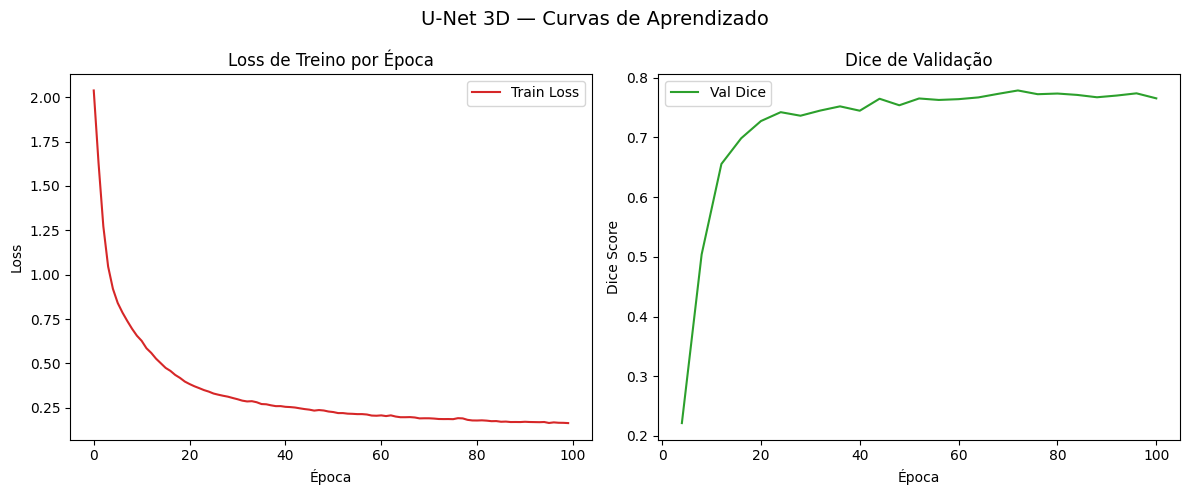

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epoch_loss_values, label='Train Loss', color='tab:red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Treino por Época')
ax1.legend()

val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
ax2.plot(val_epochs, metric_values, label='Val Dice', color='tab:green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice de Validação')
ax2.legend()

plt.suptitle('U-Net 3D — Curvas de Aprendizado', fontsize=14)
plt.tight_layout()
plt.savefig('../models/unet3d_learning_curves.png', dpi=150)
plt.show()

## 6. Avaliação Detalhada do Melhor Modelo
Carregamos o melhor checkpoint e calculamos métricas detalhadas por classe na base de validação:
- **Dice Score** por classe (NCR, ED, ET)
- **Hausdorff Distance 95** por classe (métrica oficial BraTS)
- **Sensitivity** e **Specificity** por classe

| Métrica | O que mede | Interpretação |
|---------|-----------|---------------|
| **Dice** | Sobreposição entre predição e gabarito | 0–1, maior = melhor |
| **HD95** | Hausdorff Distance 95th percentile — pior distância de fronteira | mm, menor = melhor |
| **Sensitivity** | % de voxels tumorais corretamente detectados | 0–1, maior = melhor |
| **Specificity** | % de voxels saudáveis corretamente identificados | 0–1, maior = melhor |


In [5]:
from monai.metrics import DiceMetric, HausdorffDistanceMetric, ConfusionMatrixMetric

# Carregar o melhor modelo salvo
best_model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)
best_model.load_state_dict(torch.load(os.path.join('../models', 'best_metric_model_Unet_3D.pth'), weights_only=True))
print('Modelo U-Net 3D carregado com sucesso!')
best_model.eval()

# Métricas por classe
dice_per_class = DiceMetric(include_background=False, reduction="mean_batch")
hd95_per_class = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean_batch")
sensitivity_metric = ConfusionMatrixMetric(include_background=False, metric_name='sensitivity', reduction='mean_batch')
specificity_metric = ConfusionMatrixMetric(include_background=False, metric_name='specificity', reduction='mean_batch')

post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data['image'].to(device)
        val_labels = val_data['label'].to(device)
        
        val_outputs = sliding_window_inference(
            inputs=val_inputs, roi_size=(128, 128, 128), sw_batch_size=1, predictor=best_model
        )
        
        val_outputs_list = [post_pred(i) for i in val_outputs]
        val_labels_list = [post_label(i) for i in val_labels]
        
        dice_per_class(y_pred=val_outputs_list, y=val_labels_list)
        hd95_per_class(y_pred=val_outputs_list, y=val_labels_list)
        sensitivity_metric(y_pred=val_outputs_list, y=val_labels_list)
        specificity_metric(y_pred=val_outputs_list, y=val_labels_list)

# Agregar resultados
dice_scores = dice_per_class.aggregate()
hd95_scores = hd95_per_class.aggregate()
sens_raw = sensitivity_metric.aggregate()
spec_raw = specificity_metric.aggregate()

# ConfusionMatrixMetric com mean_batch retorna lista de tensores (cada um com C elementos)
# Flatten para 1D: ex: [tensor([a,b,c])] -> tensor([a,b,c])
def to_1d(x):
    if isinstance(x, list):
        x = torch.cat([t.flatten() for t in x])
    if isinstance(x, torch.Tensor) and x.dim() > 1:
        x = x.flatten()
    return x

sens_scores = to_1d(sens_raw)
spec_scores = to_1d(spec_raw)

class_names = ['NCR (TC)', 'ED (WT)', 'ET']
header = '{:<12} {:>8} {:>10} {:>8} {:>8}'.format('Classe', 'Dice', 'HD95', 'Sens', 'Spec')
print(header)
print('-' * 50)
for i, name in enumerate(class_names):
    d = dice_scores[i].item() if hasattr(dice_scores[i], 'item') else float(dice_scores[i])
    h = hd95_scores[i].item() if hasattr(hd95_scores[i], 'item') else float(hd95_scores[i])
    s = sens_scores[i].item() if i < len(sens_scores) else 0.0
    sp = spec_scores[i].item() if i < len(spec_scores) else 0.0
    print('{:<12} {:>8.4f} {:>10.2f} {:>8.4f} {:>8.4f}'.format(name, d, h, s, sp))
print('-' * 50)
mean_dice = dice_scores.mean().item() if hasattr(dice_scores, 'mean') else float(dice_scores)
mean_hd95 = hd95_scores.mean().item() if hasattr(hd95_scores, 'mean') else float(hd95_scores)
print('{:<12} {:>8.4f} {:>10.2f}'.format('Média', mean_dice, mean_hd95))

Modelo U-Net 3D carregado com sucesso!


/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/au

Classe           Dice       HD95     Sens     Spec
--------------------------------------------------
NCR (TC)       0.7220       6.60   0.7426   0.9992
ED (WT)        0.8099      11.22   0.9069   0.9957
ET             0.8153       4.56   0.8114   0.9996
--------------------------------------------------
Média          0.7824       7.46
